## 0

### a

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


### b

In [134]:
df[['total_bill', 'tip', 'size']].describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


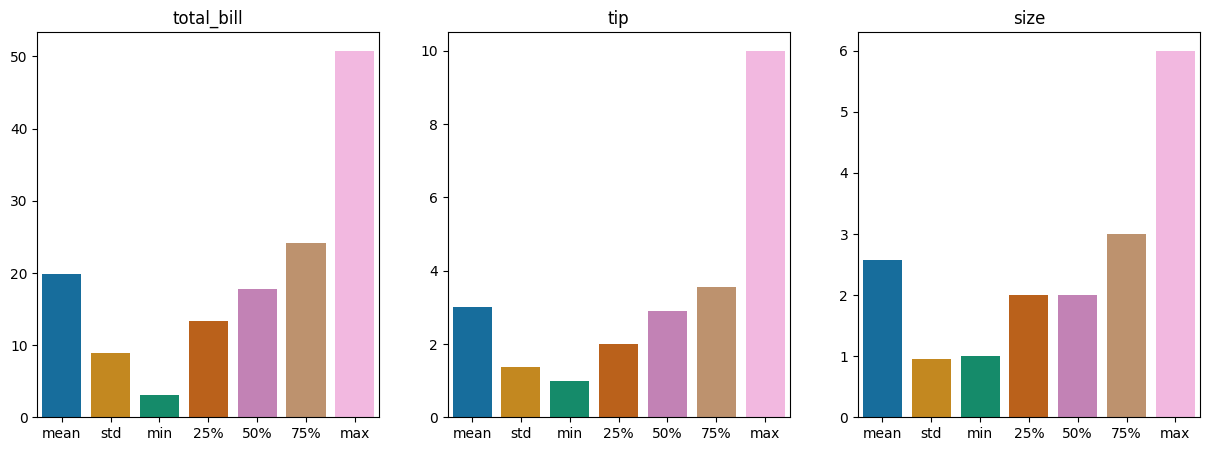

In [135]:
data = df[['total_bill', 'tip', 'size']].describe().drop("count")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(data.columns):
    sns.barplot(x=data.index, y=data[col], hue=data.index, palette='colorblind', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

### c

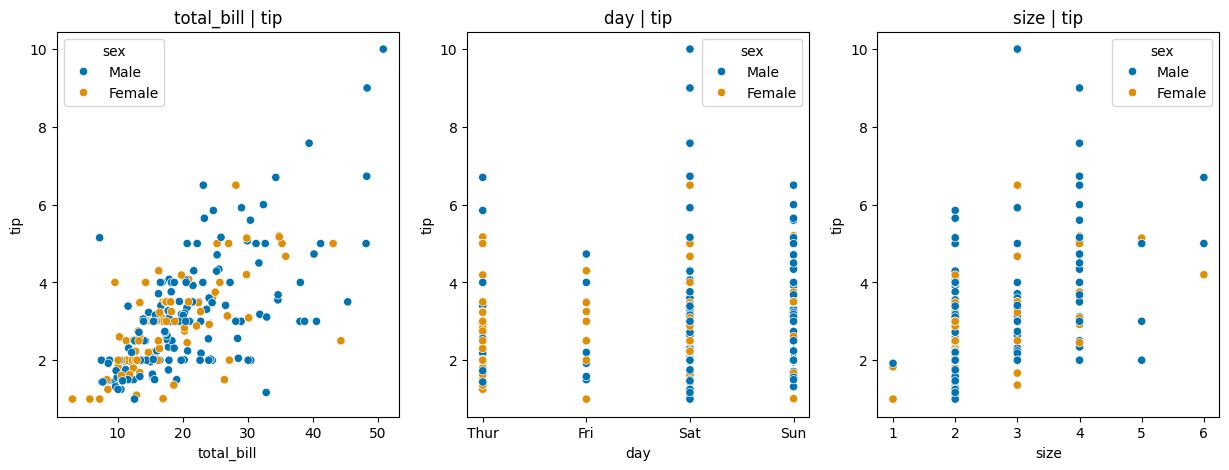

In [136]:
data = ['total_bill', 'day', 'size']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(data):
    sns.scatterplot(x=df[col], y=df['tip'], hue=df['sex'], palette='colorblind', ax=axes[i])
    axes[i].set_title(f"{col} | tip")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("tip")

In [137]:
df.groupby('sex').count()

,total_bill,tip,smoker,day,time,size
sex,,,,,,
Male,157,157,157,157,157,157
Female,87,87,87,87,87,87


## 1

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[['total_bill', 'size']], 
    df['tip'], 
    test_size=0.3,
    random_state=42)

## 2

In [139]:
def standardization(X):
    return (X - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)

scaled_X_train = standardization(X_train)
scaled_X_test = standardization(X_test)

np.mean(scaled_X_test, axis=0)

total_bill   -0.191945
size         -0.044912
dtype: float64

## 3

In [140]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

fitted_X_train = poly.fit_transform(scaled_X_train)
fitted_X_test = poly.transform(scaled_X_test)

sum(sum(fitted_X_test == poly.fit_transform(scaled_X_test))) == fitted_X_test.size

np.True_

PolynmomialFeatures deterministically maps based on degree and number of input features, not data. Therefore:

$X_{test}' = X_{test}''$

where:

$X_{test}'$ is produced by fitting on transforming data then transforming test data

$X_{test}''$ is produced by both fitting and transforming on the test data

## 4

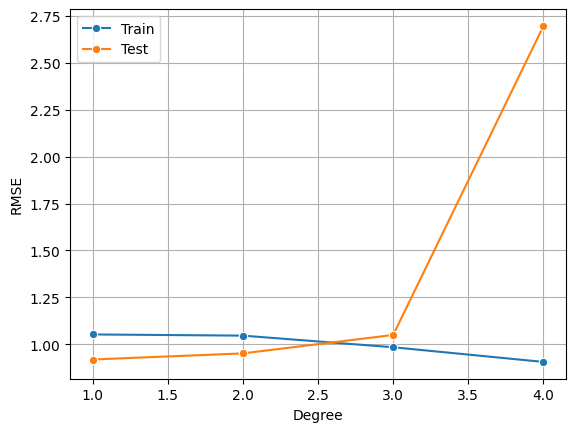

In [142]:
from sklearn.linear_model import LinearRegression
poly_reg = LinearRegression()
degrees = range(1, 5)
loss_dict = {'train_loss': [], 
                     'test_loss': []}

for i in degrees:
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(scaled_X_train)
    X_test_poly = poly.transform(scaled_X_test)

    poly_reg.fit(X=X_train_poly, y=y_train)
    train_loss = np.sqrt(np.mean(np.square(poly_reg.predict(X_train_poly) - y_train)))
    test_loss = np.sqrt(np.mean(np.square(poly_reg.predict(X_test_poly) - y_test)))

    loss_dict['train_loss'].append(train_loss)
    loss_dict['test_loss'].append(test_loss)

sns.lineplot(x=degrees, y=loss_dict['train_loss'], label="Train", marker="o")
sns.lineplot(x=degrees, y=loss_dict['test_loss'], label="Test", marker="o")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.grid()

## 5